# Chapter 1: What Breaks After You Ship

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RudrenduPaul/hardening-llm-systems-production/blob/main/companion-code/ch01-what-breaks-after-you-ship/ch01_notebook.ipynb)
## Hardening LLM Systems in Production
**Author:** Rudrendu Paul | https://orcid.org/0009-0008-0141-4690

---

### What this notebook builds

This notebook walks through the **HardeningReport** self-diagnostic scorecard introduced in Chapter 1.
The scorecard asks 25 yes/no questions across five hardening vectors and produces:

- An overall **exposure tier** (Critical exposure / Partial hardening / Defensible posture)
- A per-vector **score** (0-5, with the specific gaps listed)
- A **prioritized remediation plan** ordered by lowest-scoring vector first

Run this notebook against any LLM-powered system before its first production deployment,
and again after every major model update.

### The five hardening vectors

| Vector | Questions | What it catches |
|--------|-----------|------------------|
| Hallucination containment | HC1–HC5 | Missing automated faithfulness checks, no rollback plan |
| Adversarial hardening | AH1–AH5 | Missing privilege separation, stale red-team scans |
| Agentic safety | AS1–AS5 | System-prompt-only scope enforcement, no agent tripwires |
| Data leakage prevention | DL1–DL5 | Missing PII detection, unauthenticated vector stores |
| Compliance readiness | CR1–CR5 | Missing Annex IV artifacts, no NIST AI RMF mapping |

## Manuscript reference

This notebook demonstrates the concepts from Chapter 1 of *Hardening LLM Systems in Production* (Manning, 2026).

| Notebook section | Manuscript listing | Class / function |
|------------------|--------------------|------------------|
| LLM stack scanning | Listing 1.1 | `scan_llm_stack` |
| Incident tagging | Listing 1.2 | `tag_incident` |
| Incident classification | Listing 1.3 | `classify_incident` |
| Exposure map generation | Listing 1.4 | `generate_exposure_map` |
| Hardening scorecard | Listing 1.5 | `HardeningReport` |
| Readiness report | Listing 1.6 | `HardeningReadinessReport` |


In [1]:
# ── Colab setup ────────────────────────────────────────────────────────────
# This cell only runs when executed in Google Colab.
# Local Jupyter users: skip — all code is stdlib or pip-installable.
import sys, os

if 'google.colab' in sys.modules:
    !git clone -q https://github.com/RudrenduPaul/hardening-llm-systems-production.git
    os.chdir('hardening-llm-systems-production/companion-code/ch01-what-breaks-after-you-ship')
    print('Colab setup complete — repo cloned, packages installed.')


In [2]:
# Install pinned dependencies (run once per environment)
# Uncomment and run in Colab or a fresh virtual environment:
# !pip install requests>=2.32.0,<3.0 pydantic>=2.7.0,<3.0 matplotlib>=3.9.0,<4.0


## Setup

The HardeningReport class uses only Python standard library modules.
No pip installs required for this chapter.

In [3]:
# Verify we are running Python 3.11+
import sys
print(f"Python {sys.version}")
assert sys.version_info >= (3, 11), "Python 3.11 or higher required"

# Import the companion script module
import importlib.util, pathlib

script_path = pathlib.Path("ch01_scripts.py")
spec = importlib.util.spec_from_file_location("ch01_scripts", script_path)
ch01 = importlib.util.module_from_spec(spec)
sys.modules['ch01_scripts'] = ch01  # required for Python 3.14
spec.loader.exec_module(ch01)

print("ch01_scripts loaded successfully.")
print(f"Diagnostic questions: {len(ch01.DIAGNOSTIC_QUESTIONS)}")
print(f"Hardening vectors   : {list(ch01.VECTOR_LABELS.values())}")

Python 3.14.6 (main, Jun 10 2026, 10:03:53) [Clang 21.0.0 (clang-2100.0.123.102)]


ch01_scripts loaded successfully.
Diagnostic questions: 25
Hardening vectors   : ['Hallucination containment', 'Adversarial hardening', 'Agentic safety', 'Data leakage prevention', 'Compliance readiness']


## Section 1: The HardeningReport class

The `HardeningReport` class is the core artifact of Chapter 1.
It holds your yes/no answers and computes scores per vector and overall.

In [4]:
# Inspect the 25 questions
for i, q in enumerate(ch01.DIAGNOSTIC_QUESTIONS, 1):
    print(f"  [{q['id']}] {q['vector'][:30]:<30} {q['question'][:70]}")

  [HC1] hallucination_containment      Automated factuality evaluation (deepeval, RAGAS, or equivalent) runs 
  [HC2] hallucination_containment      RAG grounding is used for factual claims, with pipeline verification t
  [HC3] hallucination_containment      Hallucination rate is defined as a deployment-blocking metric with a d
  [HC4] hallucination_containment      Live production outputs are sampled and run through factuality evaluat
  [HC5] hallucination_containment      A documented rollback plan exists for a hallucination-rate spike in pr
  [AH1] adversarial_hardening          An automated red-team scan (Garak, PyRIT, Promptfoo, or equivalent) ra
  [AH2] adversarial_hardening          Privilege separation is implemented: the LLM cannot access more resour
  [AH3] adversarial_hardening          Output filtering catches exfiltration attempt patterns before response
  [AH4] adversarial_hardening          Injection detection tooling (Microsoft Prompt Shields, LLM Guard, or e
  [AH5] ad

## Section 2: Running the scorecard on a demo system

Three demo scenarios are pre-built to show the full output range.
The **mixed** scenario represents a realistic early-production LLM system:
some controls exist (a CI metric, a safety classifier, structured logs),
but critical gaps remain (no PII scanner, no runbook, no model registry).

In [5]:
# --- Scenario A: Mixed (realistic early-production system) ---
report_mixed = ch01.demo_report(scenario="mixed")
print(report_mixed.summary())

  HARDENING REPORT: LLM System Self-Diagnostic
  System  : Acme Customer Support Bot v2.1
  Assessor: Rudrendu Paul
  Date    : 2026-08-01

  OVERALL SCORE : 11/25 (44%, 25/25 questions answered)
  EXPOSURE TIER : Partial hardening

--------------------------------------------------------------------
  VECTOR SCORES
--------------------------------------------------------------------
  Hallucination containment    [############--------] 3/5  (60%)
  Adversarial hardening        [########------------] 2/5  (40%)
  Agentic safety               [########------------] 2/5  (40%)
  Data leakage prevention      [########------------] 2/5  (40%)
  Compliance readiness         [########------------] 2/5  (40%)

--------------------------------------------------------------------
  PRIORITIZED REMEDIATION PLAN
  (ordered by vector score, lowest first)
--------------------------------------------------------------------

  ADVERSARIAL HARDENING — 2/5 (40%)
    [01] AH2: Privilege separation is i

In [6]:
# --- Scenario B: Worst case (no controls at all) ---
report_worst = ch01.demo_report(scenario="worst")
print(report_worst.summary())

  HARDENING REPORT: LLM System Self-Diagnostic
  System  : Acme Customer Support Bot v2.1
  Assessor: Rudrendu Paul
  Date    : 2026-08-01

  OVERALL SCORE : 0/25 (0%, 25/25 questions answered)
  EXPOSURE TIER : Critical exposure

--------------------------------------------------------------------
  VECTOR SCORES
--------------------------------------------------------------------
  Hallucination containment    [--------------------] 0/5  (0%)
  Adversarial hardening        [--------------------] 0/5  (0%)
  Agentic safety               [--------------------] 0/5  (0%)
  Data leakage prevention      [--------------------] 0/5  (0%)
  Compliance readiness         [--------------------] 0/5  (0%)

--------------------------------------------------------------------
  PRIORITIZED REMEDIATION PLAN
  (ordered by vector score, lowest first)
--------------------------------------------------------------------

  HALLUCINATION CONTAINMENT — 0/5 (0%)
    [01] HC1: Automated factuality evaluati

In [7]:
# --- Scenario C: Best case (all controls in place) ---
report_best = ch01.demo_report(scenario="best")
print(report_best.summary())

  HARDENING REPORT: LLM System Self-Diagnostic
  System  : Acme Customer Support Bot v2.1
  Assessor: Rudrendu Paul
  Date    : 2026-08-01

  OVERALL SCORE : 25/25 (100%, 25/25 questions answered)
  EXPOSURE TIER : Defensible posture

--------------------------------------------------------------------
  VECTOR SCORES
--------------------------------------------------------------------
  Hallucination containment    [####################] 5/5  (100%)
  Adversarial hardening        [####################] 5/5  (100%)
  Agentic safety               [####################] 5/5  (100%)
  Data leakage prevention      [####################] 5/5  (100%)
  Compliance readiness         [####################] 5/5  (100%)

--------------------------------------------------------------------
  PRIORITIZED REMEDIATION PLAN
  (ordered by vector score, lowest first)
--------------------------------------------------------------------

  No gaps found. All 25 controls are in place.



## Section 3: Scoring your own system

Fill in your actual yes/no answers below.
Each question ID corresponds to a row in the scorecard.
Change `True`/`False` to reflect your real system state.

In [8]:
my_report = ch01.HardeningReport(
    system_name="Your System Name Here",
    assessor="Your Name",
)

# --- Hallucination containment ---
my_report.answer("HC1", False)   # Automated factuality evaluation before release?
my_report.answer("HC2", False)   # RAG grounding verified against retrieved context?
my_report.answer("HC3", False)   # Hallucination rate is a deployment-blocking metric?
my_report.answer("HC4", False)   # Continuous sampling of live outputs?
my_report.answer("HC5", False)   # Documented rollback plan for a hallucination spike?

# --- Adversarial hardening ---
my_report.answer("AH1", False)   # Red-team scan in the past 90 days?
my_report.answer("AH2", False)   # Privilege separation implemented?
my_report.answer("AH3", False)   # Output filtering for exfiltration patterns?
my_report.answer("AH4", False)   # Injection detection tooling in the request path?
my_report.answer("AH5", False)   # Documented manual red-team playbook?

# --- Agentic safety ---
my_report.answer("AS1", False)   # Execution-layer scope enforcement?
my_report.answer("AS2", False)   # Agents run with minimal privilege?
my_report.answer("AS3", False)   # Stateless tool execution?
my_report.answer("AS4", False)   # Tripwires on agent action sequences?
my_report.answer("AS5", False)   # Documented agent-scope-violation playbook?

# --- Data leakage prevention ---
my_report.answer("DL1", False)   # PII detection on inputs?
my_report.answer("DL2", False)   # PII detection on outputs?
my_report.answer("DL3", False)   # Vector store behind tenant-isolated authentication?
my_report.answer("DL4", False)   # Documented right-to-erasure implementation?
my_report.answer("DL5", False)   # Data-tier security review completed?

# --- Compliance readiness ---
my_report.answer("CR1", False)   # Classified against EU AI Act Annex III?
my_report.answer("CR2", False)   # Annex IV technical documentation maintained?
my_report.answer("CR3", False)   # Post-market monitoring within the 15-day window?
my_report.answer("CR4", False)   # Controls mapped to the NIST AI RMF?
my_report.answer("CR5", False)   # Annex IV completeness check in CI/CD?

print(my_report.summary())

  HARDENING REPORT: LLM System Self-Diagnostic
  System  : Your System Name Here
  Assessor: Your Name
  Date    : 2026-08-01

  OVERALL SCORE : 0/25 (0%, 25/25 questions answered)
  EXPOSURE TIER : Critical exposure

--------------------------------------------------------------------
  VECTOR SCORES
--------------------------------------------------------------------
  Hallucination containment    [--------------------] 0/5  (0%)
  Adversarial hardening        [--------------------] 0/5  (0%)
  Agentic safety               [--------------------] 0/5  (0%)
  Data leakage prevention      [--------------------] 0/5  (0%)
  Compliance readiness         [--------------------] 0/5  (0%)

--------------------------------------------------------------------
  PRIORITIZED REMEDIATION PLAN
  (ordered by vector score, lowest first)
--------------------------------------------------------------------

  HALLUCINATION CONTAINMENT — 0/5 (0%)
    [01] HC1: Automated factuality evaluation (deepeval,

## Section 4: Understanding the exposure tiers

Section 1.7.3's 3-tier classification, from the 0-25 total score:

| Tier | Total score | What it means |
|------|-------------|----------------|
| Defensible posture | 19-25 | Core controls are in place. Use this book to harden edge cases and integrate the PR-gate pipeline in chapter 11. |
| Partial hardening | 11-18 | Significant controls exist but material gaps remain. Use the per-vector scores to identify which chapters address the gaps. |
| Critical exposure | 0-10 | Multiple unmitigated failure surfaces. Prioritize the vector(s) with the lowest score and work through chapters 2-6 before anything else. |

In [9]:
# Compare exposure tiers across the three demo scenarios
for scenario in ["worst", "mixed", "best"]:
    r = ch01.demo_report(scenario)
    print(f"  {scenario:<8} → score={r.total_score:>2}/25  tier={r.exposure_tier.value}")

  worst    → score= 0/25  tier=Critical exposure
  mixed    → score=11/25  tier=Partial hardening
  best     → score=25/25  tier=Defensible posture


## Section 5: Visualizing vector scores

A quick bar chart showing per-vector scores across the mixed scenario.
This is the visualization you would embed in an executive dashboard.

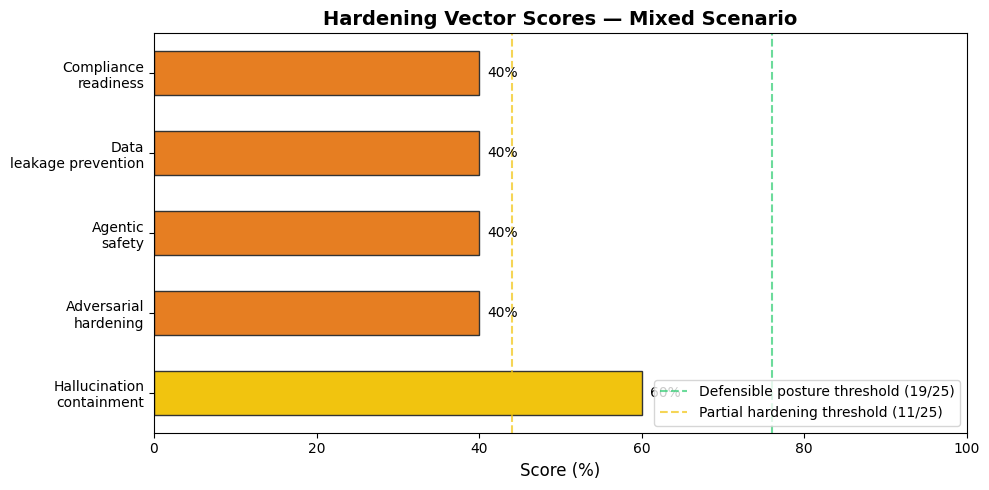

Chart saved to ch01_vector_scores.png


In [10]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    report = ch01.demo_report("mixed")
    vector_scores = report._compute_vector_scores()

    labels = [vs.label.replace(" ", "\n", 1) for vs in vector_scores.values()]
    scores = [vs.score_pct for vs in vector_scores.values()]
    colors = [
        "#2ecc71" if s >= 80 else
        "#f1c40f" if s >= 60 else
        "#e67e22" if s >= 40 else
        "#e74c3c"
        for s in scores
    ]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(labels, scores, color=colors, height=0.55, edgecolor="#333")
    ax.axvline(x=76, linestyle="--", color="#2ecc71", alpha=0.7, label="Defensible posture threshold (19/25)")
    ax.axvline(x=44, linestyle="--", color="#f1c40f", alpha=0.7, label="Partial hardening threshold (11/25)")
    ax.set_xlim(0, 100)
    ax.set_xlabel("Score (%)", fontsize=12)
    ax.set_title("Hardening Vector Scores — Mixed Scenario", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")

    for bar, score in zip(bars, scores):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                f"{score}%", va="center", fontsize=10)

    plt.tight_layout()
    plt.savefig("ch01_vector_scores.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Chart saved to ch01_vector_scores.png")

except ImportError:
    print("matplotlib not installed — skipping chart. pip install matplotlib to enable.")

## Section 6: Exporting the report to JSON

The JSON export is the format used to feed the scorecard into
automated governance dashboards, JIRA ticket generators, or Slack alerts.

In [11]:
import json

report = ch01.demo_report("mixed")
report_dict = report.to_dict()

print(json.dumps(report_dict, indent=2))

{
  "system_name": "Acme Customer Support Bot v2.1",
  "assessor": "Rudrendu Paul",
  "date": "2026-08-01",
  "total_score": 11,
  "max_score": 25,
  "overall_score_pct": 44,
  "exposure_tier": "PARTIAL",
  "exposure_tier_label": "Partial hardening",
  "answered_questions": 25,
  "total_questions": 25,
  "vectors": [
    {
      "key": "hallucination_containment",
      "label": "Hallucination containment",
      "score": 3,
      "max_score": 5,
      "chapter_reference": "Chapters 2-3",
      "gaps": [
        "HC4",
        "HC5"
      ]
    },
    {
      "key": "adversarial_hardening",
      "label": "Adversarial hardening",
      "score": 2,
      "max_score": 5,
      "chapter_reference": "Chapters 4, 6",
      "gaps": [
        "AH2",
        "AH3",
        "AH4"
      ]
    },
    {
      "key": "agentic_safety",
      "label": "Agentic safety",
      "score": 2,
      "max_score": 5,
      "chapter_reference": "Chapter 7",
      "gaps": [
        "AS1",
        "AS4",
       

In [12]:
# Save to disk
report.export_json("ch01_hardening_report.json")
print("Report saved to ch01_hardening_report.json")

Report saved to ch01_hardening_report.json
Report saved to ch01_hardening_report.json


## Section 7: Tracking score over time

The scorecard is most useful when run repeatedly, before launch, after each
major model update, and after each incident. Tracking it over time shows
whether hardening debt is accumulating or being repaid.

In [13]:
# Simulate a time series of scorecard runs
# In practice, load these from saved JSON exports

snapshots = [
    {"date": "2025-01-01", "score": 7,  "tier": "Critical exposure"},
    {"date": "2025-03-01", "score": 11, "tier": "Partial hardening"},
    {"date": "2025-06-01", "score": 15, "tier": "Partial hardening"},
    {"date": "2025-09-01", "score": 18, "tier": "Partial hardening"},
    {"date": "2026-01-01", "score": 21, "tier": "Defensible posture"},
]

print("Hardening Progress Over Time")
print("-" * 55)
for s in snapshots:
    bar = ch01._progress_bar(s["score"] / 25, width=25)
    print(f"  {s['date']}  {bar}  {s['score']:>2}/25  [{s['tier']}]")

Hardening Progress Over Time
-------------------------------------------------------
  2025-01-01  [#######------------------]   7/25  [Critical exposure]
  2025-03-01  [###########--------------]  11/25  [Partial hardening]
  2025-06-01  [###############----------]  15/25  [Partial hardening]
  2025-09-01  [##################-------]  18/25  [Partial hardening]
  2026-01-01  [#####################----]  21/25  [Defensible posture]


## Summary

This notebook built the full **HardeningReport** self-diagnostic workflow.

### What you built
- A 25-question scorecard across 5 hardening vectors
- A 3-tier exposure classification (Critical exposure / Partial hardening / Defensible posture)
- A prioritized remediation plan ordered by lowest-scoring vector first
- JSON export for integration with governance dashboards

### Next steps
1. **Chapter 2**, Run `HallucinationMetric` from deepeval and RAGAS faithfulness scoring to close the HC1 gap.
2. **Chapter 3**, Wire the hallucination gate into your GitHub Actions CI pipeline to close HC1 systematically.
3. **Chapter 4**, Add prompt injection defense to close AH2–AH4.
4. **Chapter 5**, Secure your RAG retrieval layer and vector store to address DL3.
5. Re-run this scorecard after each chapter's implementation to track your exposure tier improving.